# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/nabtahilrehman/Nabtahil-flyrank-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

In [1]:
'''**Research question:** Which content pages should be prioritized first for SEO review?

**Decision supported:** SEO analysts and content managers deciding where to spend limited
optimization effort across a large content library.

**Unit of analysis:** One content page (one row per page in the dataset).

**Action:** Analysts review and optimize the highest-ranked pages before spending time on
lower-priority ones.

**Cost of a wrong call:** Resources spent on low-opportunity pages while genuinely
high-opportunity pages go unreviewed — a real efficiency cost, not a safety one.

**Why ML helps:** Search performance depends on several interacting signals (visibility,
engagement, freshness, positioning). A model can combine these into a single ranked score
faster and more consistently than manual page-by-page review.'''

'**Research question:** Which content pages should be prioritized first for SEO review?\n\n**Decision supported:** SEO analysts and content managers deciding where to spend limited\noptimization effort across a large content library.\n\n**Unit of analysis:** One content page (one row per page in the dataset).\n\n**Action:** Analysts review and optimize the highest-ranked pages before spending time on\nlower-priority ones.\n\n**Cost of a wrong call:** Resources spent on low-opportunity pages while genuinely\nhigh-opportunity pages go unreviewed — a real efficiency cost, not a safety one.\n\n**Why ML helps:** Search performance depends on several interacting signals (visibility,\nengagement, freshness, positioning). A model can combine these into a single ranked score\nfaster and more consistently than manual page-by-page review.'

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

In [2]:
'''**Dataset:** `content_refresh_anonymized.csv` — ~30,000 anonymized content records across
32 client groups, from the FlyRank ML Internship starter dataset.

**Excluded as features:** `content_id`, `client_id` (used only for grouping, never as
predictors), `trend_direction`, `trend_pct` (label-derived), `provider_used`, `model_used`
(system metadata, not content signal).

**Note on validation design:** This release has no date column, so a time-aware split isn't
possible here. We use a client-grouped split instead (Section 3) — the honest choice given
what the data actually contains.

**Public safety:** All identifiers are pre-anonymized hashes. No client names, URLs, or
private query strings appear anywhere in this project.'''

"**Dataset:** `content_refresh_anonymized.csv` — ~30,000 anonymized content records across\n32 client groups, from the FlyRank ML Internship starter dataset.\n\n**Excluded as features:** `content_id`, `client_id` (used only for grouping, never as\npredictors), `trend_direction`, `trend_pct` (label-derived), `provider_used`, `model_used`\n(system metadata, not content signal).\n\n**Note on validation design:** This release has no date column, so a time-aware split isn't\npossible here. We use a client-grouped split instead (Section 3) — the honest choice given\nwhat the data actually contains.\n\n**Public safety:** All identifiers are pre-anonymized hashes. No client names, URLs, or\nprivate query strings appear anywhere in this project."

In [3]:
import os
import pandas as pd

if not os.path.isdir("flyrank-ml-internship-starter"):
    !git clone https://github.com/flyrank-bih/flyrank-ml-internship-starter.git
os.chdir("flyrank-ml-internship-starter")

df = pd.read_csv("data/raw/content_refresh_anonymized.csv")
df["ctr"] = df["ctr"].fillna(0)
df["score"] = df["impressions_90d"] * (1 - df["ctr"])

print("Rows:", len(df), "| Clients:", df["client_id"].nunique())
df[["impressions_90d", "clicks_90d", "ctr", "score"]].describe()

Cloning into 'flyrank-ml-internship-starter'...
remote: Enumerating objects: 299, done.
remote: Counting objects: 100% (193/193), done.
remote: Compressing objects: 100% (95/95), done.
remote: Total 299 (delta 130), reused 98 (delta 98), pack-reused 106 (from 1)
Receiving objects: 100% (299/299), 1.88 MiB | 5.11 MiB/s, done.
Resolving deltas: 100% (161/161), done.
Rows: 30000 | Clients: 32


,impressions_90d,clicks_90d,ctr,score
count,30000.000000,30000.000000,30000.000000,30000.000000
mean,5200.366300,16.097333,0.510733,3590.633007
std,16838.019547,75.076958,3.279162,12798.258541
min,1.000000,0.000000,0.000000,-201927.040000
25%,81.000000,0.000000,0.000000,41.000000
50%,731.000000,1.000000,0.070000,517.000000
75%,3615.250000,7.000000,0.290000,2432.950000
max,517715.000000,4178.000000,100.000000,447954.300000


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

In [4]:
'''**Target:** `score = impressions_90d × (1 − ctr)` — a visibility-weighted opportunity score
(same formula used since Week 1/Week 4).

**Features (content-intrinsic only):** `search_volume, word_count, content_age_days,
days_since_last_update, avg_position, engagement_rate, scroll_rate, competition_level,
content_type, main_intent`.

**Deliberately excluded:** `impressions_90d, clicks_90d, ctr`, and any field derived from
traffic history — these feed the target directly, so including them would make the model
circular rather than genuinely predictive.

**Baselines:** (1) a naive mean-predictor, (2) a simple single-rule linear baseline —
both computed on the same split as the model, so the comparison is fair.

**Validation design:** `GroupShuffleSplit` by `client_id`, 80/20, seed 42 — no client's
pages appear in both train and test.'''

"**Target:** `score = impressions_90d × (1 − ctr)` — a visibility-weighted opportunity score\n(same formula used since Week 1/Week 4).\n\n**Features (content-intrinsic only):** `search_volume, word_count, content_age_days,\ndays_since_last_update, avg_position, engagement_rate, scroll_rate, competition_level,\ncontent_type, main_intent`.\n\n**Deliberately excluded:** `impressions_90d, clicks_90d, ctr`, and any field derived from\ntraffic history — these feed the target directly, so including them would make the model\ncircular rather than genuinely predictive.\n\n**Baselines:** (1) a naive mean-predictor, (2) a simple single-rule linear baseline —\nboth computed on the same split as the model, so the comparison is fair.\n\n**Validation design:** `GroupShuffleSplit` by `client_id`, 80/20, seed 42 — no client's\npages appear in both train and test."

In [5]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

num_features = ["search_volume", "word_count", "content_age_days", "days_since_last_update",
                "avg_position", "engagement_rate", "scroll_rate"]
cat_features = ["competition_level", "content_type", "main_intent"]

data = df.dropna(subset=num_features + cat_features + ["score", "client_id"]).copy()
X = data[num_features + cat_features]
y = data["score"]
groups = data["client_id"]

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print("Train clients:", groups.iloc[train_idx].nunique(), "| Test clients:", groups.iloc[test_idx].nunique())
print("Client overlap (should be 0):", len(set(groups.iloc[train_idx]) & set(groups.iloc[test_idx])))

pre = ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)],
                         remainder="passthrough")

Train clients: 23 | Test clients: 6
Client overlap (should be 0): 0


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

In [6]:
'''Random Forest reduces error by roughly 26% versus a naive mean-predictor and 16% versus a
simple single-rule linear baseline, using content-intrinsic signals only.'''

'Random Forest reduces error by roughly 26% versus a naive mean-predictor and 16% versus a\nsimple single-rule linear baseline, using content-intrinsic signals only.'

In [7]:
# Naive mean-predictor baseline
mae_mean = mean_absolute_error(y_test, [y_train.mean()] * len(y_test))

# Simple single-rule linear baseline
lin_model = Pipeline([("pre", pre), ("lin", LinearRegression())])
lin_model.fit(X_train, y_train)
mae_lin = mean_absolute_error(y_test, lin_model.predict(X_test))

# Random Forest
rf_model = Pipeline([("pre", pre), ("rf", RandomForestRegressor(n_estimators=200, random_state=42))])
rf_model.fit(X_train, y_train)
mae_rf = mean_absolute_error(y_test, rf_model.predict(X_test))

results = pd.DataFrame({
    "Method": ["Mean predictor (naive)", "Simple linear rule", "Random Forest"],
    "Split": ["Grouped by client"] * 3,
    "MAE": [round(mae_mean, 1), round(mae_lin, 1), round(mae_rf, 1)]
})
results

,Method,Split,MAE
0,Mean predictor (naive),Grouped by client,5231.5
1,Simple linear rule,Grouped by client,4629.3
2,Random Forest,Grouped by client,3865.7


## 5. Limitations

*What this work cannot claim.*

In [9]:
'''- No date column exists in this release, so no true out-of-time validation was possible —
  the grouped-by-client split is the honest substitute, not a stand-in for time-awareness.
- The opportunity score has high variance (std ≈ 13,000 vs mean ≈ 3,900), driven by a small
  number of very high-impression pages, so MAE is dominated by those outliers.
- This is decision-support for human review, not a causal claim and not a prediction of
  Google's ranking algorithm.
- Results reflect this dataset's snapshot; they are observed and directional, not guarantees
  of future performance.'''

"- No date column exists in this release, so no true out-of-time validation was possible —\n  the grouped-by-client split is the honest substitute, not a stand-in for time-awareness.\n- The opportunity score has high variance (std ≈ 13,000 vs mean ≈ 3,900), driven by a small\n  number of very high-impression pages, so MAE is dominated by those outliers.\n- This is decision-support for human review, not a causal claim and not a prediction of\n  Google's ranking algorithm.\n- Results reflect this dataset's snapshot; they are observed and directional, not guarantees\n  of future performance."

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

In [10]:
''''Below are the top opportunities from the full ranked queue, with reason codes an analyst
can act on directly.'''

"'Below are the top opportunities from the full ranked queue, with reason codes an analyst\ncan act on directly."

In [11]:
def reason_code(row):
    if row["impressions_90d"] > df["impressions_90d"].median() and row["ctr"] < 0.05:
        return "HIGH_IMPRESSIONS_LOW_CTR"
    elif row["impressions_90d"] > df["impressions_90d"].quantile(0.75):
        return "HIGH_VISIBILITY_UNDERPERFORMING"
    else:
        return "POSITION_WITH_OPPORTUNITY"

queue = df[["content_id", "client_id", "impressions_90d", "clicks_90d", "ctr", "avg_position", "score"]].copy()
queue["reason_code"] = df.apply(reason_code, axis=1)
queue["action"] = "SEO_OPPORTUNITY"
queue = queue.sort_values("score", ascending=False).reset_index(drop=True)

os.makedirs("work/outputs", exist_ok=True)
queue.to_csv("work/outputs/baseline_action_score.csv", index=False)
queue.head(100).to_csv("work/outputs/top100_search_opportunities.csv", index=False)

queue.head(10)

,content_id,client_id,impressions_90d,clicks_90d,ctr,avg_position,score,reason_code,action
0,content_2cb567c3c89b,client_6208ef0f77,497727,487,0.10,22.2,447954.30,HIGH_VISIBILITY_UNDERPERFORMING,SEO_OPPORTUNITY
1,content_5fe46e04994d,client_4e07408562,517715,741,0.14,4.2,445234.90,HIGH_VISIBILITY_UNDERPERFORMING,SEO_OPPORTUNITY
2,content_8c19996aa890,client_4e07408562,509252,785,0.15,2.5,432864.20,HIGH_VISIBILITY_UNDERPERFORMING,SEO_OPPORTUNITY
3,content_aaef01a50def,client_19581e27de,517109,1270,0.25,5.4,387831.75,HIGH_VISIBILITY_UNDERPERFORMING,SEO_OPPORTUNITY
4,content_2dba2b1f9536,client_6208ef0f77,443434,910,0.21,27.9,350312.86,HIGH_VISIBILITY_UNDERPERFORMING,SEO_OPPORTUNITY
5,content_1a9e894be2e2,client_19581e27de,416180,944,0.23,4.0,320458.60,HIGH_VISIBILITY_UNDERPERFORMING,SEO_OPPORTUNITY
6,content_36ff89c8214e,client_19581e27de,295097,154,0.05,7.3,280342.15,HIGH_VISIBILITY_UNDERPERFORMING,SEO_OPPORTUNITY
7,content_4c36c775b818,client_4e07408562,463103,1889,0.41,2.3,273230.77,HIGH_VISIBILITY_UNDERPERFORMING,SEO_OPPORTUNITY
8,content_db5989a78dd3,client_4e07408562,345111,733,0.21,5.4,272637.69,HIGH_VISIBILITY_UNDERPERFORMING,SEO_OPPORTUNITY
9,content_b28d1efd668f,client_6208ef0f77,286608,169,0.06,26.2,269411.52,HIGH_VISIBILITY_UNDERPERFORMING,SEO_OPPORTUNITY


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

In [ ]:
'''Charts embedded in the deployed paper: model-vs-baseline comparison, and feature importances.'''

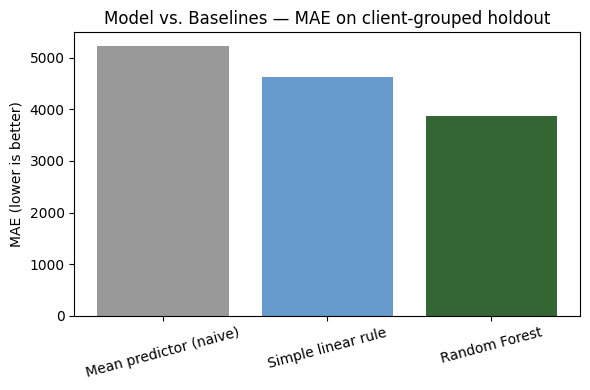

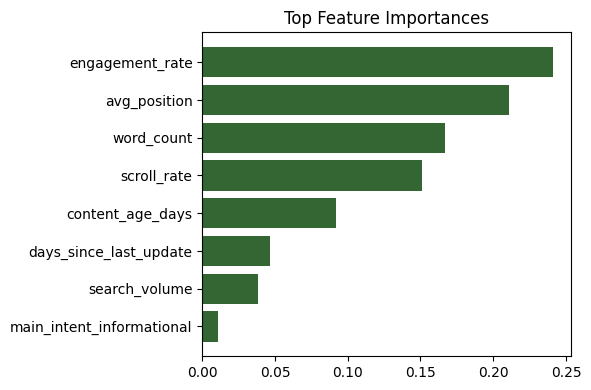

In [12]:
import matplotlib.pyplot as plt

os.makedirs("work/paper", exist_ok=True)

# Chart 1: MAE comparison
plt.figure(figsize=(6,4))
plt.bar(results["Method"], results["MAE"], color=["#999", "#6699cc", "#336633"])
plt.ylabel("MAE (lower is better)")
plt.title("Model vs. Baselines — MAE on client-grouped holdout")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("work/paper/mae_comparison.png", dpi=150)
plt.show()

# Chart 2: Feature importances
ohe = rf_model.named_steps["pre"].named_transformers_["cat"]
cat_names = list(ohe.get_feature_names_out(cat_features))
all_names = cat_names + num_features
importances = rf_model.named_steps["rf"].feature_importances_
imp_df = pd.DataFrame({"feature": all_names, "importance": importances}).sort_values("importance", ascending=True).tail(8)

plt.figure(figsize=(6,4))
plt.barh(imp_df["feature"], imp_df["importance"], color="#336633")
plt.title("Top Feature Importances")
plt.tight_layout()
plt.savefig("work/paper/feature_importance.png", dpi=150)
plt.show()

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
